In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt # THIS ISN't FUNCTIONAL, IT's JUST TEMPORARY
import time
words = open('names.txt', 'r').read().splitlines()

In [ ]:
class Value:
    def __init__(self, data, _children=(), _opp="", label=""):
        self.data = np.array(data)
        self.prev = set(_children)
        self.grad = np.zeros_like(self.data, dtype=float)
        self.opp = _opp
        self.label = label
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) #Make it still work if other is an integer and not a Value (a+1, for instance)
        
        def _unbroadcast(grad, shape):
            # sum over axes that were broadcast
            while grad.ndim > len(shape):
                grad = grad.sum(axis=0)
            for i, dim in enumerate(shape):
                if dim == 1:
                    grad = grad.sum(axis=i, keepdims=True)
            return grad
        
        def _backward():
            self.grad += _unbroadcast(out.grad, self.data.shape)
            other.grad += _unbroadcast(out.grad, other.data.shape)

        out = Value(self.data+other.data, (self, other), "+")
        out._backward = _backward
        return out
    
    def __matmul__(self, other):
        out = Value(self.data @ other.data, (self, other), "@")
        def _backward():
            self.grad += out.grad @ other.data.T
            other.grad += self.data.T @ out.grad
        
        out._backward = _backward
        
        return out
    
    def __radd__(self, other):
        return self + other

    def __sub__(self, other):
        return self + (-other)

    def __neg__(self):
        return self * -1
    
    def __mul__(self, other):
        def _unbroadcast(grad, shape):
            # sum over axes that were broadcast
            while grad.ndim > len(shape):
                grad = grad.sum(axis=0)
            for i, dim in enumerate(shape):
                if dim == 1:
                    grad = grad.sum(axis=i, keepdims=True)
            return grad


        other = other if isinstance(other, Value) else Value(other)
        def _backward():
            self.grad += _unbroadcast(other.data * out.grad, self.data.shape)
            other.grad += _unbroadcast(self.data * out.grad, other.data.shape)

        out = Value(self.data * other.data, (self, other), "*")
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other
        #Add support for integer * Value (since 2*a doesn't work, but a*2 does)
    
    def __truediv__(self, other):
        return self * other**-1
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "not an int or float"
        out = Value(self.data**other, (self, ), f"**{other}")

        def _backward():
            self.grad += other * (self.data ** (other-1)) * out.grad
        out._backward = _backward
        return out
    
    def __len__(self):
        return len(self.data)
    
    def tanh(self):
        x=self.data
        t = np.tanh(x)

        def _backward():
            self.grad += (1-t**2) * out.grad

        out = Value(t, (self, ), "tanh")
        out._backward=_backward
        return out
    
    def exp(self):
        x=self.data

        def _backward():
            self.grad += (np.exp(x)*out.data)

        out = Value(np.exp(x), (self, ), "exp")
        out._backward=_backward
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v.prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        self.grad = np.ones_like(self.data)

        for node in reversed(topo):
            node._backward()

#Helper function
def oneHot(c):
    out = [0 for _ in range(27)]
    curIndex = ord(c)-97
    if curIndex <0:
        curIndex=26 # Change it if it's a period
    out[curIndex] = 1
    return out
def cross_entropy(logits, targets):
    e = np.exp(logits.data)
    probs = e / e.sum(axis=1, keepdims=True)
    
    correct_probs = probs[np.arange(len(targets)), targets]
    loss = -np.log(correct_probs).mean()
    
    out = Value(loss, (logits,), "cross_entropy")
    
    def _backward():
        # gradient of cross entropy + softmax combined is just (probs - 1_correct) / batch_size
        dlogits = probs.copy()
        dlogits[np.arange(len(targets)), targets] -= 1
        dlogits /= len(targets)
        logits.grad += dlogits
    
    out._backward = _backward
    return out
def prog(val, total):
    length = 20
    out = "["
    for i in range(length):
        if i < math.ceil((val/total) * length):
            out += "#"
        else:
            out += "-"
    return out + "]"
def trunc(number, digits):
    stepper = 10 ** digits
    return math.trunc(number * stepper) / stepper


In [3]:
# defining weights
W1 = Value(np.random.randn(30, 200) * (5/3) / (30**0.5))  # embedding_size * block_size -> hidden
#b1 = Value(np.zeros(200))
W2 = Value(np.random.randn(200, 27) * 0.01)  # hidden -> logits 
b2 = Value(np.zeros(27))
charEncodings = Value(np.random.randn(27,10)) #Increase to 10 dimensional embeddings
bngain = Value(np.ones((1, 200)))
bnbias = Value(np.zeros((1, 200)))

parameters = [charEncodings, W1, W2, b2, bngain, bnbias] # for easy access during 
finished = 0
lossGraph=[]
bnmean_running = Value(np.zeros((1, 200)))
bnstd_running = Value(np.ones((1, 200)))

In [ ]:
stoi = {s:i for i,s in enumerate(sorted(list(set(''.join(words)))))}
stoi['.']=26
itos = {i:s for s,i in stoi.items()}

blockSize = 3
inputs, outputs = [],[]

In [5]:
for w in words:
    context = [0] * blockSize # start with 3 starting characters
    for ch in w + '.':
        ix = stoi[ch] # get the current character
        inputs.append(context) # add input to inputs, output to outputs
        outputs.append(ix)
        context = context[1:] + [ix] # update the context

In [ ]:
n1 = int(.8 * len(inputs))
n2 = int(.9 * len(inputs))

trainIn = inputs[:n1] # Training data (80%)
trainOut = outputs[:n1]
devIn = inputs[n1:n2] # Development data (10%) For use on like testing random ideas, etc
devOut = outputs[n1:n2]
testIn = inputs[n2:] #  Test data (10%) 
testOut = outputs[n2:]

In [ ]:
def forward(Value, cross_entropy, W1, W2, b2, charEncodings, parameters, inputs, outputs, epoch=0):
    # Encode the inputs
    batch = [random.randint(0, len(inputs)-1) for _ in range(32)] #  get 32 random indexes (indexii? indeces? idk)

    enc = [[0 for _ in range(len(inputs[0]))] for i in range(len(batch))]
  
    for input in range(len(batch)):
        for c in range(len(inputs[batch[input]])):
            enc[input][c] = charEncodings.data[inputs[batch[input]][c]]

    #resize the inputs
    for input in range(len(enc)):
        out = []
        for letter in enc[input]:
            out.extend(letter)
        enc[input] = out

    enc = Value(enc)

    # Now for the forward pass
    h = enc @ W1 #+ b1 # Pre hidden layer Need to add batch normalization, which is when we standardize the hidden layer std.
    bnmeani = np.mean(h.data, 0)
    bnstdi = np.std(h.data, 0)
    h = (h - bnmeani) / (bnstdi + 1e-5) # Batch normalization! Prevents loss of data in the tanh function
    # The 1e-5 is an epsilon value to prevent division by zero! (ε)
    h = h * bngain + bnbias # Scale and shift the normalized values
    
    bnmean_running.data = 0.999 * bnmean_running.data + 0.001 * bnmeani
    bnstd_running.data = 0.999 * bnstd_running.data + 0.001 * bnstdi

    h = h.tanh() # Hidden layer
    logits = h @ W2 + b2

    # Now loss calculation
    loss = cross_entropy(logits, [outputs[x] for x in batch])

    #print(loss) 

    loss.backward()

    if epoch < 150000:
        lr = -.1
    else:
        lr = -.01

    for p in parameters:
        p.data += lr * p.grad
        p.grad = np.zeros_like(p.data, dtype=float)

def forwardNoTrain(Value, cross_entropy, W1, W2, b2, charEncodings, parameters, inputs, outputs, epoch=0):
    # Encode the inputs
    batch = [random.randint(0, len(inputs)-1) for _ in range(32)] #  get 32 random indexes (indexii? indeces? idk)

    enc = [[0 for _ in range(len(inputs[0]))] for i in range(len(batch))]
  
    for input in range(len(batch)):
        for c in range(len(inputs[batch[input]])):
            enc[input][c] = charEncodings.data[inputs[batch[input]][c]]

    #resize the inputs
    for input in range(len(enc)):
        out = []
        for letter in enc[input]:
            out.extend(letter)
        enc[input] = out

    enc = Value(enc)

    # Now for the forward pass
    h = enc @ W1 #+b1
    h = (h - np.mean(h.data, 0)) / np.std(h.data, 0) #Added the batch normalization for the testing set
    h = h * bngain + bnbias
    h = h.tanh()
    logits = h @ W2 + b2


    # Now loss calculation
    loss = cross_entropy(logits, [outputs[x] for x in batch])

    return loss

In [8]:
epochs = 20000000
START_TIME = time.perf_counter()
print(f"Started training Makemore ({epochs} epochs)")
trainTemp = -1
testTemp = -1
for i in range(epochs):
    if (i%50==0):
        train_loss = trunc(forwardNoTrain(Value, cross_entropy, W1, W2, b2, charEncodings, parameters, trainIn, trainOut, i).data, 3)
        test_loss  = trunc(forwardNoTrain(Value, cross_entropy, W1, W2, b2, charEncodings, parameters, testIn,  testOut,  i).data, 3)
        trainTemp, testTemp = train_loss, test_loss
        lossGraph.append(test_loss)
    else:
        train_loss = trainTemp
        test_loss = trainTemp
    forward(Value, cross_entropy, W1, W2, b2, charEncodings, parameters, trainIn, trainOut, i)
    finished += 1
    print(f"\rTrained {i+1} epochs.", end="")

print(f"\nTotal Trained: {finished}")

Started training Makemore (20000000 epochs)
Trained 14045 epochs.

KeyboardInterrupt: 

In [9]:
trunc(forwardNoTrain(Value, cross_entropy, W1, W2, b2, charEncodings, parameters, testIn,  testOut,  i).data, 3)

2.211

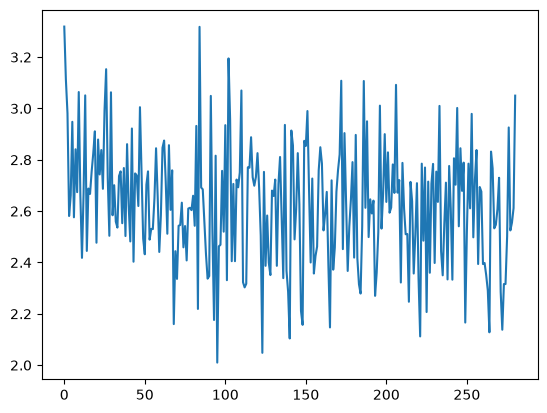

In [10]:
plt.plot(lossGraph)

In [11]:
# Calibrate the batch norm for at the end of training so a single example can be used clearly.
# We no longer need this because we calculate a running total.

# Get the embeddings
# Get the preaction function
# Get the average and standard deviation of that preaction function

enc = [[0 for _ in range(len(trainIn[0]))] for i in range(len(trainIn))]
for input in range(len(trainIn)):
    for c in range(len(trainIn[input])):
        enc[input][c] = charEncodings.data[trainIn[input][c]]

for input in range(len(enc)):
    out = []
    for letter in enc[input]:
        out.extend(letter)
    enc[input] = out

enc = Value(enc)

hpreact = enc @ W1 # No b1

bnmean = np.mean(hpreact.data, 0, keepdims=True)
bnstd  = np.std(hpreact.data, 0, keepdims=True)

print(bnmean)
print(bnstd)

[[ 0.73403618 -0.94407514  1.07318379  0.12625691 -0.97080682  0.27839757
  -0.04425279  1.64667575 -0.19431878 -0.80941583 -0.8403574  -0.77073625
  -0.94755928  0.3740563  -1.94005639  0.35808172 -1.42781436  1.22899116
  -0.54244079 -0.35670133  0.44246606 -0.78726011  1.54362995 -2.68538794
  -0.10707827  0.39626082  0.15256849 -0.05821912  0.6661682   0.66848558
   1.03721143 -0.0028997   0.05939708 -0.96532695 -0.61059128 -0.14400837
   1.55365304 -0.28796613  0.12490267  0.65039108  0.23714105  1.04404844
   0.0056087  -0.71993976  0.60205971 -0.52479531 -0.49691191 -1.68847428
  -1.05309618 -1.80281473 -0.7636675  -0.98628892 -1.92917346  0.26536989
   0.44699658  1.39330899 -0.02814148  0.54179972 -2.17878942 -0.85793979
   0.14181947 -0.47463179  0.28391076  0.6701104   0.18110401  1.36233694
  -0.64908019  0.80256041  2.74856609 -0.1619639  -0.23873841  0.27099395
  -0.93027956  1.17999379  0.32879183  0.64622262  0.28025169  1.5282497
  -1.66331817 -0.55428    -0.81307467  

In [12]:
def predict():
    out = "..."

    #First pass
    enc = [[0,0,0]]
    for c in range(3):
        enc[0][c] = charEncodings.data[26] # THis is over the top bc I didn't want to redo everything, but it just puts in the index of starting character.

    #resize the inputs
    for input in range(len(enc)):
        flat = []
        for letter in enc[input]:
            flat.extend(letter)
        enc[input] = flat

    enc = Value(enc)

    h = enc @ W1
    h = (h - bnmean_running.data) / (bnstd_running.data + 1e-5)
    h = h * bngain + bnbias
    h = h.tanh()
    logits = h @ W2 + b2
    e = np.exp(logits.data)
    probs = e / e.sum(axis=1, keepdims=True)
    reverse = {v: k for k, v in stoi.items()}

    while len(out) < 50:
        # rest of name
        enc = [[0,0,0]]
        for c in range(3):
            enc[0][c] = charEncodings.data[stoi[out[-3+c]]]

        #resize the inputs
        for input in range(len(enc)):
            flat = []
            for letter in enc[input]:
                flat.extend(letter)
            enc[input] = flat

        enc = Value(enc)

        h = enc @ W1
        h = (h - bnmean_running.data) / (bnstd_running.data + 1e-5)
        h = h * bngain + bnbias
        h = h.tanh()
        logits = h @ W2 + b2
        e = np.exp(logits.data)
        probs = e / e.sum(axis=1, keepdims=True)
        reverse = {v: k for k, v in stoi.items()} 
        out += reverse[np.random.choice(27, p=probs[0])]
        if out[-1] == '.':
            break
    
    print(out[3:-1])

In [13]:
for i in range(20):
    predict()

yah
o
adelya
a
aleira
abriamartey
ynn
kadevy
azeliyah
lmi
amtikannett
aleigh
andy
ah
mbna
aiahnianna
akyleah
s
an
arnzerielyn


In [14]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = Value(np.random.randn(fan_in, fan_out) / fan_in**0.5)
        self.bias = Value(np.zeros(fan_out)) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])



class BatchNorm1D:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained via backprop)
        self.gamma = Value(np.ones(dim))
        self.beta = Value(np.zeros(dim))
        # buffers (updated with a running average, not backprop)
        self.running_mean = np.zeros(dim)
        self.running_var = np.ones(dim)

    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean = np.mean(x.data, axis=0, keepdims=True) # batch mean
            xvar = np.var(x.data, axis=0, keepdims=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / (xvar + self.eps) ** .5 # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar

        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = x.tanh()
        return self.out
    def parameters(self):
        return []

n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
vocab_size = 27

C = Value(np.random.randn(vocab_size, n_embd))
layers = [
  Linear(n_embd * blockSize, n_hidden, bias=False), BatchNorm1D(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1D(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1D(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1D(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1D(n_hidden), Tanh(),
  Linear(           n_hidden, vocab_size, bias=False), BatchNorm1D(vocab_size),
]

# layers = [
#   Linear(n_embd * blockSize, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, vocab_size),
# ]

# last layer: make less confident
layers[-1].gamma.data *= 0.1
# all other layers: apply gain
for layer in layers[:-1]:
    if isinstance(layer, Linear):
        layer.weight.data *= 1.0 #5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.data.size for p in parameters)) # number of parameters in total


47024


In [ ]:
max_steps = 200000
batch_size = 32
lossi = []
ud = []

trainInArr = np.array(trainIn)   # (N, blockSize) context indices
trainOutArr = np.array(trainOut) # (N,) target indices

for i in range(max_steps):

    # minibatch construct
    ix = np.random.randint(0, trainInArr.shape[0], (batch_size,))
    Xb, Yb = trainInArr[ix], trainOutArr[ix]

    # forward pass
    emb = C.data[Xb] # embed the characters into vectors (batch, blockSize, n_embd)
    x = Value(emb.reshape(emb.shape[0], -1)) # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = cross_entropy(x, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = np.zeros_like(p.data, dtype=float)
    loss.backward()

    # update
    lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {float(loss.data):.4f}')
    lossi.append(np.log10(float(loss.data)))
    ud.append([np.log10(np.std(lr * p.grad) / np.std(p.data)) for p in parameters])

    if i >= 1000:
        #break # If you want to.
        pass


      0/ 200000: 1.9753


C:\Users\28taidan\AppData\Local\Temp\ipykernel_33128\590543802.py:36: RuntimeWarning: divide by zero encountered in log10
  ud.append([np.log10(np.std(lr * p.grad) / np.std(p.data)) for p in parameters])


  10000/ 200000: 1.9003
  20000/ 200000: 1.8016
  30000/ 200000: 1.8771
  40000/ 200000: 2.0224
  50000/ 200000: 2.1094
  60000/ 200000: 1.7805
  70000/ 200000: 2.2634
  80000/ 200000: 2.3288
  90000/ 200000: 1.6690
 100000/ 200000: 1.9135
 110000/ 200000: 1.9347
 120000/ 200000: 1.8900


layer 2 (      Tanh): mean -0.02, std 0.91, saturated: 59.16%
layer 5 (      Tanh): mean +0.04, std 0.93, saturated: 68.03%
layer 8 (      Tanh): mean +0.01, std 0.93, saturated: 68.59%
layer 11 (      Tanh): mean -0.02, std 0.96, saturated: 75.44%
layer 14 (      Tanh): mean +0.05, std 0.95, saturated: 75.09%


Text(0.5, 1.0, 'activation distribution')

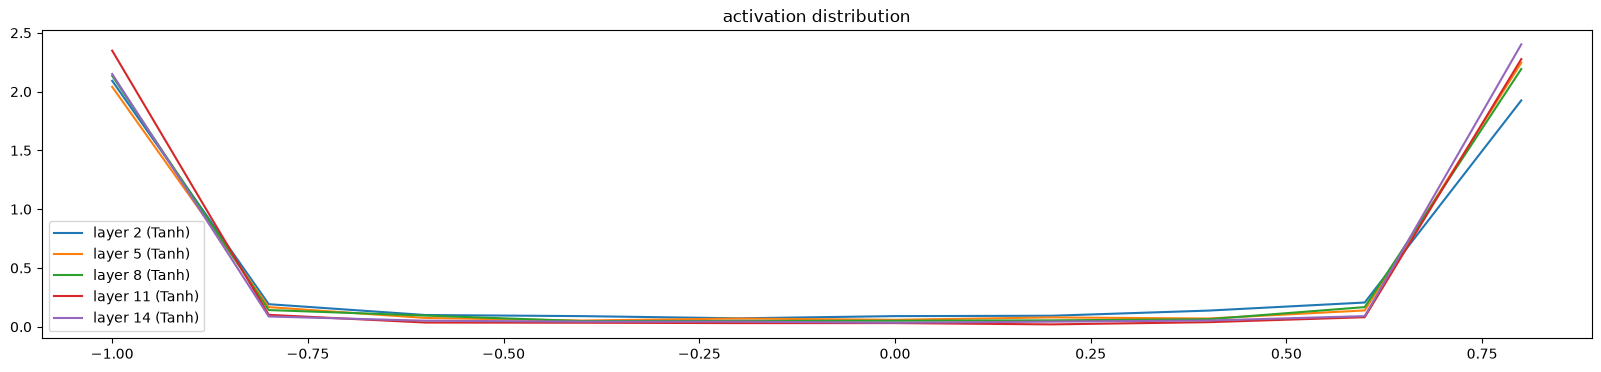

In [46]:
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out.data
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (
            i, layer.__class__.__name__, t.mean(), t.std(), (np.abs(t) > 0.97).mean() * 100))
        hy, hx = np.histogram(t, density=True)
        plt.plot(hx[:-1], hy)
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('activation distribution')


In [55]:
# put batchnorm layers into eval mode so they use the running stats instead of
# per-batch stats (a batch of size 1 has zero variance, which would blow up otherwise)
for layer in layers:
    if isinstance(layer, BatchNorm1D):
        layer.training = False

# sample from the model
rng = np.random

for _ in range(20):

    out = []
    context = [26] * blockSize # initialize with the '.' padding token
    while True:
        # forward pass the neural net
        emb = C.data[context] # (blockSize, n_embd)
        x = Value(emb.reshape(1, -1)) # concatenate the vectors
        for layer in layers:
            x = layer(x)
        logits = x
        e = np.exp(logits.data)
        probs = e / e.sum(axis=1, keepdims=True)
        # sample from the distribution
        ix = rng.choice(vocab_size, p=probs[0])
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 26:
            break

    print(''.join(itos[i] for i in out[:-1])) # decode and print the generated word, dropping the trailing '.'


yedayteet
eea
ith
yaxie
eightone



is
yeastasmini
is
ito
yah
ynn
is
nel
yah
i
yiah
yah


In [ ]:
import json
import os

def export_weights(path='docs/weights.json'):
    # make sure batchnorm layers use running stats, matching the sampling cell above
    for layer in layers:
        if isinstance(layer, BatchNorm1D):
            layer.training = False

    model = {
        "blockSize": blockSize,
        "vocabSize": vocab_size,
        "nEmbd": n_embd,
        "itos": {str(k): v for k, v in itos.items()},
        "C": C.data.tolist(),
        "layers": [],
    }
    for layer in layers:
        if isinstance(layer, Linear):
            model["layers"].append({
                "type": "linear",
                "weight": layer.weight.data.tolist(),
                "bias": layer.bias.data.tolist() if layer.bias is not None else None,
            })
        elif isinstance(layer, BatchNorm1D):
            # running_mean/var start as (dim,) but broadcast to (1, dim) after the
            # first training step, so flatten everything to guarantee 1-D arrays for
            # the web app. (A nested [[...]] makes the JS index into undefined -> NaN,
            # so the model only ever emits the stop token and every name comes out empty.)
            model["layers"].append({
                "type": "batchnorm",
                "gamma": np.asarray(layer.gamma.data).reshape(-1).tolist(),
                "beta": np.asarray(layer.beta.data).reshape(-1).tolist(),
                "runningMean": np.asarray(layer.running_mean).reshape(-1).tolist(),
                "runningVar": np.asarray(layer.running_var).reshape(-1).tolist(),
                "eps": layer.eps,
            })
        elif isinstance(layer, Tanh):
            model["layers"].append({"type": "tanh"})

    dirname = os.path.dirname(path)
    if dirname:
        os.makedirs(dirname, exist_ok=True)
    with open(path, 'w') as f:
        json.dump(model, f)
    print(f"Wrote {path} ({os.path.getsize(path)/1024:.1f} KB)")

export_weights()


Wrote web/weights.json (998.3 KB)


In [ ]:
# dlogprobs = np.zeros_like(logprobs)
# dlogprobs[range(n), Yb] = -1.0/n
# dprobs = (1.0 / probs) * dlogprobs
# dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)
# dcounts = counts_sum_inv * dprobs
# dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv
# dcounts += np.ones_like(counts) * dcounts_sum_inv
# dnorm_logits = counts + dcounts
# dlogits = dnorm_logits.clone()
# dlogitmaxes  (-dnorm_logits).sum(1, keepdim=True)
# dlogits = F.onehot(logits.max(1).indices, numclasses=logits.shape[1]) ( dlogitmaxes)

# This bit should be ignored
# It's from lecture 4 on Backpropogation, where he implemented backpropogation manually, instead of pyTorch's loss.backward()
# However, I already implemented it, since I'm not using Pytorch and had to write the .backward function myself.
# So I just (tried to) follow along with the excercizes in the lecture and ensured that my code was free from errors.